#Hyperparameter_Tuning = Hyperparameter_Optimization

What is Hyperparameter Tuning?

Hyperparameter tuning is the process of systematically searching for the optimal combination of hyperparameters for a machine learning model to achieve the best performance on a given task.


##Hyperparameters vs. Parameters:

Parameters: Values that the model learns from the data during training

Hyperparameters: Configuration settings that are set BEFORE training and control the learning process itself

#Types of Hyperparameter Tuning :

1- Grid Search

2- Randome Search

#Grid Search
##What is Grid Search?

Grid Search is an search method that evaluates every possible combination of hyperparameters from a predefined grid. It's systematic but computationally expensive.

#Random Search
##What is Random Search?

Randomized Search randomly samples a fixed number of hyperparameter combinations from specified distributions. It's more efficient than Grid Search, especially for high-dimensional spaces.

#Example

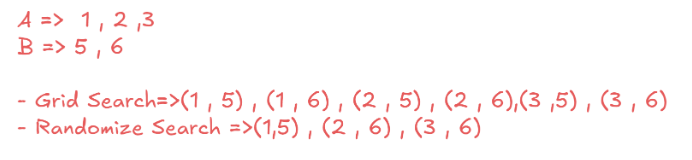

#Grid Search

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
import pandas as pd

# Load dataset
df=pd.read_csv("/content/iris.csv")


#Split the data
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
trials = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 4]
}

# Grid Search
grid_search = GridSearchCV(estimator=rf, param_grid=trials , scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best hyperparameters and score
print("Best Hyperparameters (Grid Search):", grid_search.best_params_)
print("Best Accuracy (Grid Search):", grid_search.best_score_)


Best Hyperparameters (Grid Search): {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best Accuracy (Grid Search): 0.95


#Random Search

In [3]:
from sklearn.model_selection import RandomizedSearchCV # new
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

import pandas as pd

# Load dataset
df=pd.read_csv("/content/iris.csv")


#Split the data
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Define model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5],
    'min_samples_split': [2, 4]
}

# Grid Search
grid_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid , scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best hyperparameters and score
print("Best Hyperparameters (Grid Search):", grid_search.best_params_)
print("Best Accuracy (Grid Search):", grid_search.best_score_)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Hyperparameters (Grid Search): {'n_estimators': 50, 'min_samples_split': 4, 'max_depth': 5}
Best Accuracy (Grid Search): 0.95


#Another Example

#1- Split the data

In [5]:

from sklearn.model_selection import train_test_split
import pandas as pd

# Load real dataset
df=pd.read_csv("/content/breast_cancer.csv")

# split the data
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



# 2- Call the model

In [6]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)


# 3- Use Grid Search to define the hyper_parameters

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid Search Best Params:", grid_search.best_params_)
print("Grid Search Best Accuracy:", grid_search.best_score_)


Grid Search Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Grid Search Best Accuracy: 0.9604395604395606


#4-Randomized Search

In [8]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 4, 6, 8],

}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Randomized Search Best Params:", random_search.best_params_)
print("Randomized Search Best CV Accuracy:", random_search.best_score_)


Randomized Search Best Params: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 30}
Randomized Search Best CV Accuracy: 0.9582417582417584
